In [1]:
import bw2data, bw2io
#from premise import *
#import bw_timex
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime

In [2]:
# activate the bw project
bw2data.projects.set_current("ei311")
for db in bw2data.databases:
    print(db, len(bw2data.Database(db)))

ecoinvent-3.11-biosphere 9795
ecoinvent-3.11-cutoff 25412
ei_cutoff_3.11_remind_SSP2-NDC_2030 2025-11-21 37360
ei_cutoff_3.11_remind_SSP2-NDC_2040 2025-11-21 37361
ei_cutoff_3.11_remind_SSP2-NDC_2050 2025-11-21 37361
ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22 41755
ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22 41754
ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24 41774
elec_foreground 1


## step1: prepare dynamic LCI 

In [3]:
image_ssp1_db_2030 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24")
image_ssp1_db_2040 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22")
image_ssp1_db_2050 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22")

In [4]:
if "elec_foreground" in bw2data.databases:
    del bw2data.databases["elec_foreground"]  
foreground = bw2data.Database("elec_foreground")
foreground.register()

### create new foreground DB
#### need foreground helper:: 
- depending on which location, e.g., CAN, or any other location provided by the premise background database, we'll create a final elec_highvol_loc_1kwh, as the new foreground activity to be assigned with dynamic inventory 

####  need background SSP/year mapping helper:: 
- e.g., if we're studying 2030 elec grid for image_ssp1, then using the image_ssp1_db_2030 background database to search for bw2_act: "market group for electricity, high voltage", also location == user-input location e.g., "CAN"

In [5]:
elec_ssp1_2040_production = image_ssp1_db_2040.get(name="market group for electricity, high voltage", location="CAN")
print(elec_ssp1_2040_production)

'market group for electricity, high voltage' (kilowatt hour, CAN, None)


In [6]:
elec_highvol_CAN_1kwh = foreground.new_node("elec_highvol_CAN_1kwh", 
                                            name="electricity mix, high voltage, Canada", 
                                            location = "CAN", unit="kWh")

elec_highvol_CAN_1kwh['reference product'] = "one kWh electricity mix, high voltage"
elec_highvol_CAN_1kwh.new_edge(input=elec_highvol_CAN_1kwh, amount=1, type="production").save()

### because temporal_distribution MUST be attached to the exchange, not the activity in bw_temporalis ###
input_elec_to_highvol_CAN_1kwh = elec_highvol_CAN_1kwh.new_edge(
    input=elec_ssp1_2040_production,
    amount=1,
    type="technosphere",
)

elec_highvol_CAN_1kwh.save()

In [7]:
len(elec_highvol_CAN_1kwh.technosphere())

0

In [8]:
elec_highvol_CAN_1kwh.as_dict()

{'database': 'elec_foreground',
 'code': 'elec_highvol_CAN_1kwh',
 'location': 'CAN',
 'name': 'electricity mix, high voltage, Canada',
 'unit': 'kWh',
 'reference product': 'one kWh electricity mix, high voltage'}

In [9]:
input_elec_to_highvol_CAN_1kwh

Exchange: 1 kilowatt hour 'market group for electricity, high voltage' (kilowatt hour, CAN, None) to 'electricity mix, high voltage, Canada' (kWh, CAN, None)>

<Axes: xlabel='Time (Years)', ylabel='Amount'>

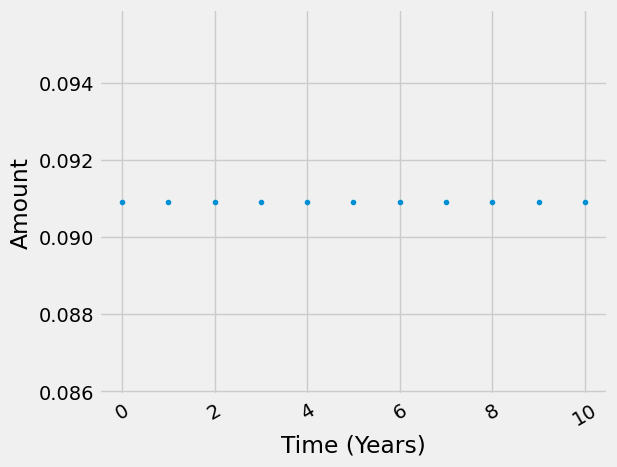

In [10]:
elec_MY = 10

td_elec = easy_timedelta_distribution(
    start=0,
    end=elec_MY,
    resolution="Y",
    steps=(elec_MY + 1),
    kind="uniform",  
)
td_elec.graph(resolution="Y") 
# if `M` month resolution, so later tlca.build_timeline(temporal_grouping="month") 

In [11]:
input_elec_to_highvol_CAN_1kwh["temporal_distribution"] = td_elec
input_elec_to_highvol_CAN_1kwh.save()

## map to background premise

#### mapping foreground -> background datetime helper:: 
- it's important to choose the right background database and datetime for the dynamic foreground:
- e.g., if we're studying 2040&ssp1 electricity, like above elec_ssp1_2040_production = image_ssp1_db_2040.get, then the database_dates ={} below use the same SSP/year e.g.,  image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),

    
    database_dates = {
        #image_ssp1_db_2030.name: datetime.strptime("2030", "%Y"),
        image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),
        #image_ssp1_db_2050.name: datetime.strptime("2050", "%Y"),
        "elec_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
    }

In [12]:
database_dates = {
    #image_ssp1_db_2030.name: datetime.strptime("2030", "%Y"),
    image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),
    #image_ssp1_db_2050.name: datetime.strptime("2050", "%Y"),
    "elec_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

database_dates

{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.datetime(2040, 1, 1, 0, 0),
 'elec_foreground': 'dynamic'}

### ready to instanciate tlca

In [13]:
method =  ('ecoinvent-3.11',
  'IPCC 2021 (incl. biogenic CO2)',
  'climate change: total (incl. biogenic CO2, incl. SLCFs)',
  'global warming potential (GWP100)')  
 
#('ecoinvent-3.11', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)') 


In [14]:
tlca = TimexLCA({elec_highvol_CAN_1kwh: 1}, method, database_dates)

2025-11-25 19:57:02.892 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2025-11-25 19:57:02.893 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


In [15]:
# build a timeline of the exchanges: if `M` for td, then month here 
tlca.build_timeline(temporal_grouping="year")

2025-11-25 19:57:07.259 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2025-11-25 19:57:10.197 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2025-11-25 19:57:15.513 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2025-11-25 19:57:15.731 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...
2025-11-25 19:57:15.879 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...
2025-11-25 19:57:15.900 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-25 19:57:15.901 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provi

Starting graph traversal
Calculation count: 1


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2026-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
1,2026-01-01,"electricity mix, high voltage, Canada",2026-01-01,-1,1.0,None
2,2027-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
3,2028-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
4,2029-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
5,2030-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
6,2031-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
7,2032-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
8,2033-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...
9,2034-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-...


In [16]:
# calculate the time-explicit LCI, with TimexLCA.lci()
tlca.lci()

2025-11-25 19:57:16.280 | INFO     | bw_timex.timex_lca:lci:360 - Expanding matrices...
2025-11-25 19:57:16.299 | INFO     | bw_timex.timex_lca:lci:379 - Calculating dynamic inventory...


In [17]:
tlca.dynamic_inventory # the new dynamic_inventory that was now created,
# instead of one row for each emission in the biosphere database we now get one row for each emission at each point in time.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30635 stored elements and shape (36102, 41802)>

In [18]:
tlca.dynamic_inventory.shape
# w/h three background DB datatime, it becomes (36102, 125365) 

(36102, 41802)

In [19]:
#the dynamic inventory is calculated as a sparse matrix, more human-friendly version as a pandas:
tlca.dynamic_inventory_df

,date,amount,flow,activity
2212,2026-01-01,2.583415e+00,250401799139369058,251340274252521474
612,2026-01-01,1.960198e+00,250401797902049299,251340274252521474
280,2026-01-01,4.815651e-01,250401797688139822,251340274252521474
273,2026-01-01,3.238203e-01,250401797688139804,251340274252521474
1343,2026-01-01,3.237697e-01,250401798346645610,251340274252521474
...,...,...,...,...
29936,2036-01-01,-2.218689e-12,250401799051288591,251340274252521485
29908,2036-01-01,-4.711480e-12,250401799005151256,251340274252521485
28665,2036-01-01,-4.912797e-12,250401798036267024,251340274252521485
30126,2036-01-01,-1.732092e-11,250401799198089261,251340274252521485


In [21]:
### dynamic lci with the static GWP 
tlca.static_lcia()
tlca.static_score   #kg CO2-eq

-0.030488291601568678

In [20]:
#tlca.dynamic_lcia(metric="radiative_forcing", fixed_time_horizon=True)
tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon = 100)
tlca.dynamic_score

2025-11-25 19:57:41.445 | INFO     | dynamic_characterization.dynamic_characterization:characterize:82 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


0.12366576424167698

## step2:: some plot / analysis on dyn-LCI/LCIA 

### plot dynamic inventory per emission flow

In [26]:
co2_fossil = [x for x in mybio if 'Carbon dioxide, fossil' in str(x)] 
ch4_fossil = [x for x in mybio if 'Methane, fossil' in str(x)]  
print(len(co2_fossil), len(ch4_fossil))

5 4


In [27]:
ch4_bio = [x for x in mybio if 'Methane, non-fossil' in str(x)]  
ch4_bio

['Methane, non-fossil' (kilogram, None, ('air', 'urban air close to ground')),
 'Methane, non-fossil' (kilogram, None, ('air', 'low population density, long-term')),
 'Methane, non-fossil' (kilogram, None, ('air',)),
 'Methane, non-fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))]

In [28]:
ch4_bio[2].as_dict()

{'categories': ('air',),
 'code': 'da1157e2-7593-4dfd-80dd-a3449b37a4d8',
 'CAS number': '000074-82-8',
 'synonyms': ['Methane'],
 'name': 'Methane, non-fossil',
 'database': 'ecoinvent-3.11-biosphere',
 'unit': 'kilogram',
 'type': 'emission',
 'id': 250401798745104436}

In [29]:
co2_fossil[3].as_dict()

{'categories': ('air', 'lower stratosphere + upper troposphere'),
 'code': '16eeda8a-1ea2-408e-ab37-2648495058dd',
 'CAS number': '000124-38-9',
 'synonyms': ['Carbon dioxide'],
 'name': 'Carbon dioxide, fossil',
 'database': 'ecoinvent-3.11-biosphere',
 'unit': 'kilogram',
 'type': 'emission',
 'id': 250401797780414511}

In [30]:
ch4_fossil[0].as_dict()

{'categories': ('air',),
 'code': '0795345f-c7ae-410c-ad25-1845784c75f5',
 'CAS number': '000074-82-8',
 'synonyms': ['Methane'],
 'name': 'Methane, fossil',
 'database': 'ecoinvent-3.11-biosphere',
 'unit': 'kilogram',
 'type': 'emission',
 'id': 250401797683945508}

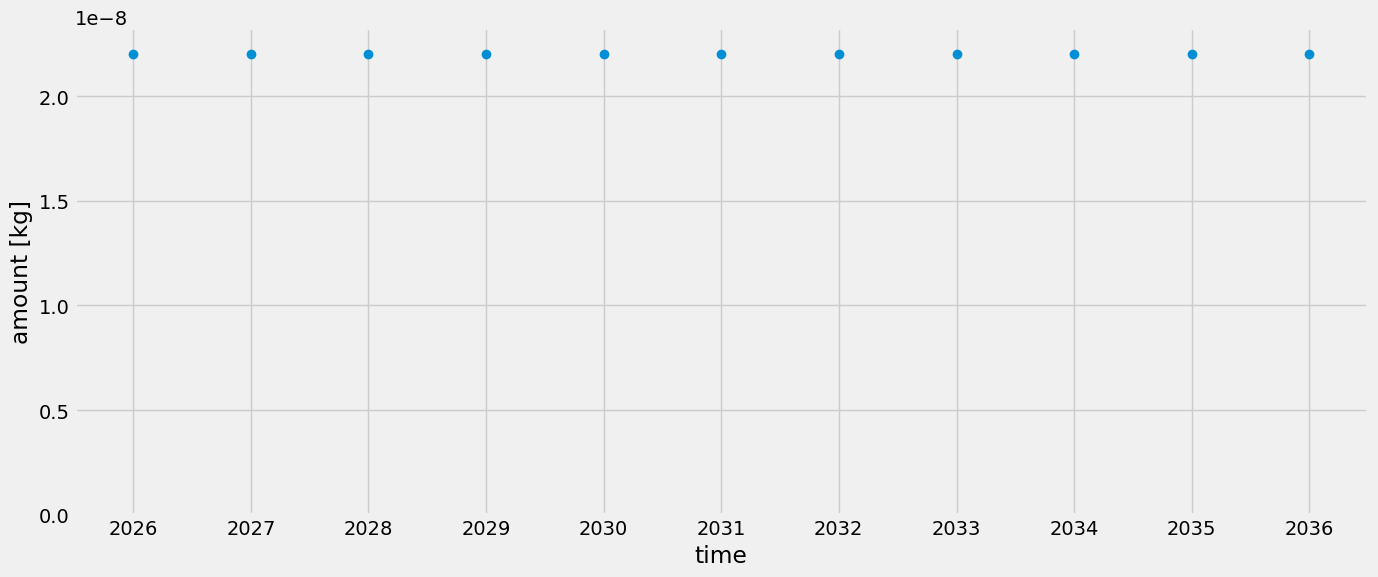

In [31]:
tlca.plot_dynamic_inventory(bio_flows = [250401798745104436]) #ch4-non fossil

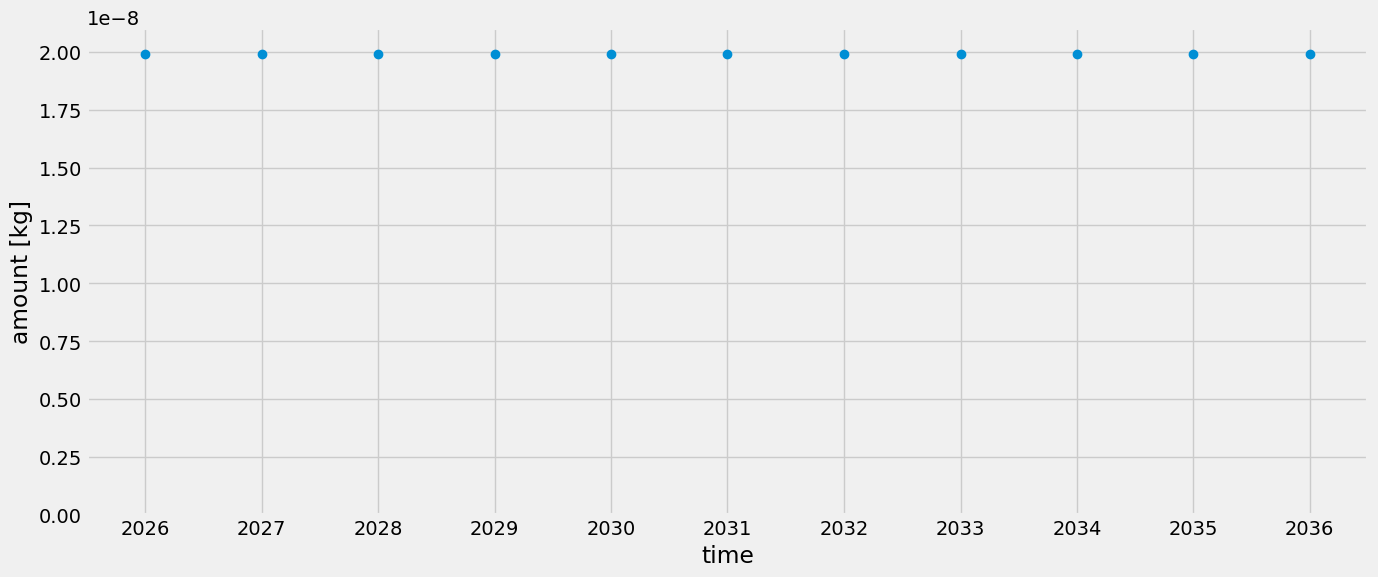

In [32]:
tlca.plot_dynamic_inventory(bio_flows = [250401797683945508]) #ch4-fossil 

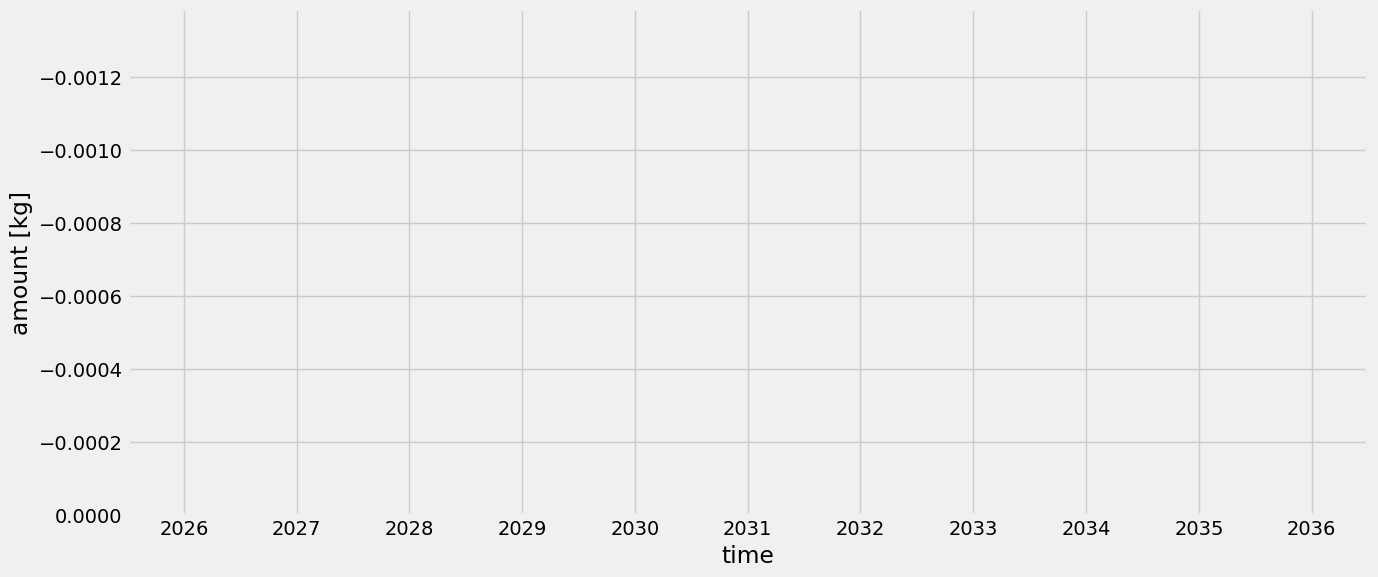

In [33]:
tlca.plot_dynamic_inventory(bio_flows = [250401798669606930]) #co2

In [34]:
df = tlca.dynamic_inventory_df
df_co2_air = df[df['flow'] == 250401798669606930] 
df_co2_air

,date,amount,flow,activity
1729,2026-01-01,-0.001466,250401798669606930,251340274252521474
4514,2027-01-01,-0.001466,250401798669606930,251340274252521476
7299,2028-01-01,-0.001466,250401798669606930,251340274252521477
10084,2029-01-01,-0.001466,250401798669606930,251340274252521478
12869,2030-01-01,-0.001466,250401798669606930,251340274252521479
15654,2031-01-01,-0.001466,250401798669606930,251340274252521480
18439,2032-01-01,-0.001466,250401798669606930,251340274252521481
21224,2033-01-01,-0.001466,250401798669606930,251340274252521482
24009,2034-01-01,-0.001466,250401798669606930,251340274252521483
26794,2035-01-01,-0.001466,250401798669606930,251340274252521484


###  why  fixed_time_horizon=False: 

- Fixed time horizon means that the time horizon for all emissions (no matter when they occur) starts counting at the time of the functional unit, resulting in shorter time horizons for emissions occuring later. This approach has been proposed by Levasseur et al. 2010 to harmonize the time frame chosen for the analysis and the time period covered by the LCA results. If the time horizon is not fixed (this is what conventional impact assessment factors assume), it starts counting from the timing of the emission.

In [35]:
#tlca.dynamic_lcia(metric="radiative_forcing", fixed_time_horizon=True)
tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon = 100)
tlca.dynamic_score

2025-11-25 20:01:30.122 | INFO     | dynamic_characterization.dynamic_characterization:characterize:82 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


0.12366576424167698

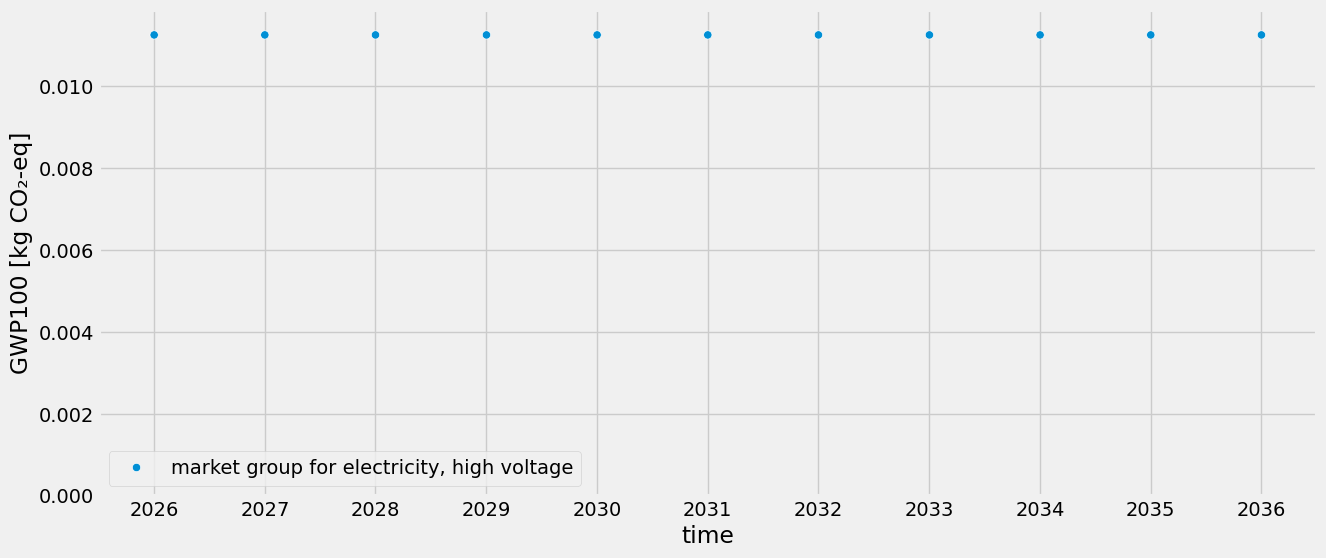

In [36]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)

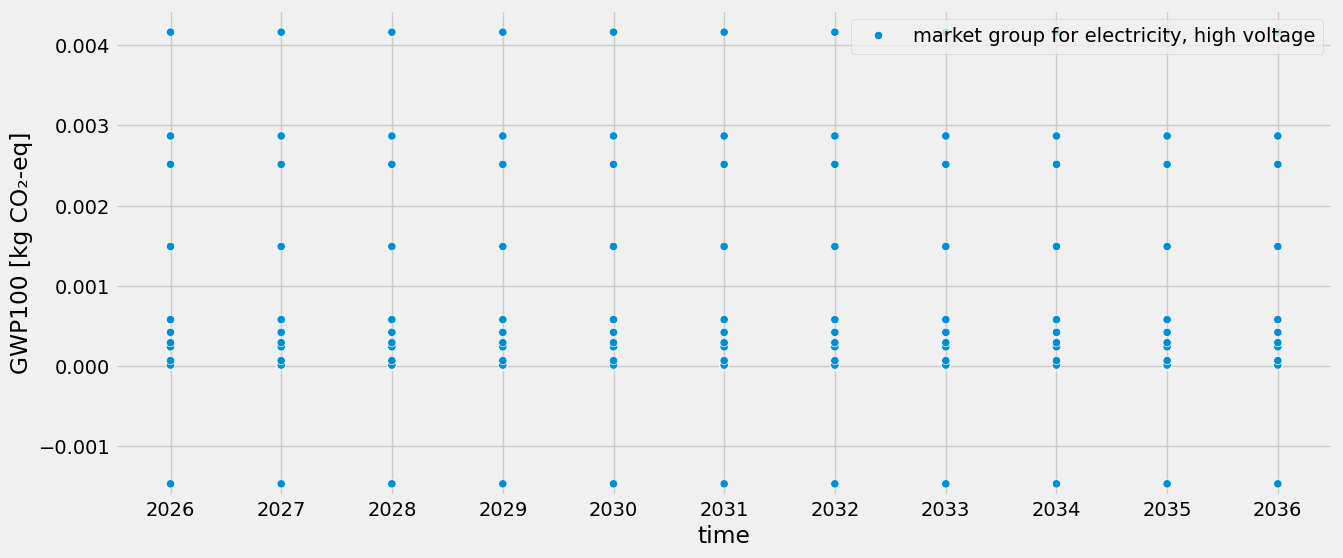

In [37]:
# plots each emission flow as a separate time series::
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=False)

## step3:: filter out GHG flows, for the new dpGWP LCIA 

In [22]:
mybio = bw2data.Database('ecoinvent-3.11-biosphere')

In [23]:
df = tlca.dynamic_inventory_df
#[x for x in mybio if 'Carbon dioxide, fossil' in str(x)][0].as_dict()

In [24]:
#df
#all_ef = np.unique(df['flow'] )
#print(len(all_ef))

In [25]:
from bw2data import get_activity

method = ('ecoinvent-3.11',
  'IPCC 2021 (incl. biogenic CO2)',
  'climate change: total (incl. biogenic CO2, incl. SLCFs)',
  'global warming potential (GWP100)')  

loaded_m = bw2data.Method(method).load()   

flow_dict = {}

# keep all the ghg flows in a meta dict, with keys as the flow 'id'
for fid, cf in loaded_m:         
    act = get_activity(fid)
    flow_dict[fid] = act.as_dict()


df_ghg = df[df['flow'].isin(flow_dict.keys())].copy()

df_ghg

,date,amount,flow,activity
621,2026-01-01,4.163197e-03,250401797923020800,251340274252521474
2167,2026-01-01,2.869412e-03,250401799114203150,251340274252521474
574,2026-01-01,2.515586e-03,250401797876883529,251340274252521474
2155,2026-01-01,1.491888e-03,250401799110008870,251340274252521474
2658,2026-01-01,5.804681e-04,250401799567187993,251340274252521474
...,...,...,...,...
29997,2036-01-01,1.152072e-17,250401799110008842,251340274252521485
28247,2036-01-01,2.510449e-21,250401797755248741,251340274252521485
29739,2036-01-01,9.897443e-32,250401798837379133,251340274252521485
30224,2036-01-01,7.623153e-33,250401799277781018,251340274252521485


In [48]:
df_year_agg = (
    df.groupby(['year', 'flow'], as_index=False)
      .agg({'amount': 'sum'})
)

In [49]:
df_year_agg

,year,flow,amount
0,2026,250401797453258752,7.932527e-18
1,2026,250401797453258766,1.112640e-10
2,2026,250401797453258768,2.971286e-08
3,2026,250401797453258769,2.931021e-20
4,2026,250401797453258770,5.079233e-18
...,...,...,...
30630,2036,250401799659462718,1.014173e-12
30631,2036,250401799659462722,1.316604e-16
30632,2036,250401799659462727,1.509524e-07
30633,2036,250401799659462730,1.513620e-19


In [43]:
#for flow_id in all_ef: 
    #flow = [x for x in mybio if str(x.as_dict()['id']) == str(flow_id)] 
    #if len(flow) == 1:
    #    if flow[0]('type') == 'emission'
    #        print(flow[0]['name']) 
    #else:
    #    print(f"no unique flow found {len(flow)}")


Flurochloridone
Phenol
Solids, inorganic
Prothioconazole
Sulfadiazine
Pentachlorobenzene
Azinphos-methyl
Thiobencarb
Carbon
m-Xylene
Transformation, to dump site
Mancozeb
Iodine-131
Flurochloridone
Chlorothalonil
Transformation, to annual crop, irrigated
Phosphorus
Dibenz(a,h)anthracene
Terbuthylazin
Ethyl benzene
Radium-226
Beryllium II
Copper oxide
Acrylate
Cyanide
Bromate
Propaquizafop
Carbon disulfide
Ethylene oxide
Beryllium II
Peracetic acid
Barium II
Acetamiprid
Spirotetramat
Radon-220
Dioxins, measured as 2,3,7,8-tetrachlorodibenzo-p-dioxin
Magnesium
Hydrocarbons, unspecified
Cupric hydroxide
Beryllium II
Uranium-238
Aluminium III
Lambda-cyhalothrin
Hydrogen peroxide
Acetamiprid
Isobutanol
Dinitrogen monoxide
Phosphorus
Diquat
Transformation, from dump site, residual material landfill
Chlorimuron-ethyl
Paraquat
Oxydemeton-methyl
Iridium
Mecoprop-P
t-Butyl amine
Copper ion
Transformation, to pasture, man made, extensive
Chlorothalonil
Butene
Trinexapac-ethyl
Vanadium V
Boron
Met